<a href="https://colab.research.google.com/github/selvapreethi2006-hue/Customer-segmentation-using-cluster/blob/main/Customer_segmentation_using_cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [3]:
#Load the data
from google.colab import files
uploaded = files.upload()   # a "Choose Files" button appears; select Mall_Customers.csv


Saving Mall_Customers_v2.csv to Mall_Customers_v2 (1).csv


In [4]:
df = pd.read_csv("Mall_Customers_v2.csv")
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,43,55,44
1,2,Male,30,59,54
2,3,Male,41,87,19
3,4,Female,23,19,78
4,5,Male,47,31,21


In [5]:
#Understand the data
df.info()
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   36.710000           59.745000               49.945000
std     57.879185    9.707579           24.549611               25.783442
min      1.000000   18.000000           15.000000                7.000000
25%     50.750000   30.000000           47.000000               20.750000
50%    100.500000   36.000000         

In [6]:
#Data cleaning
# Missing values
print(df.isnull().sum())

# Duplicates
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

# Rename columns for easier use
df = df.rename(columns={
    "Annual Income (k$)": "Income",
    "Spending Score (1-100)": "Spending"
})

# Encode Gender
df["Gender_Code"] = df["Gender"].map({"Male": 0, "Female": 1})

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Duplicates: 0


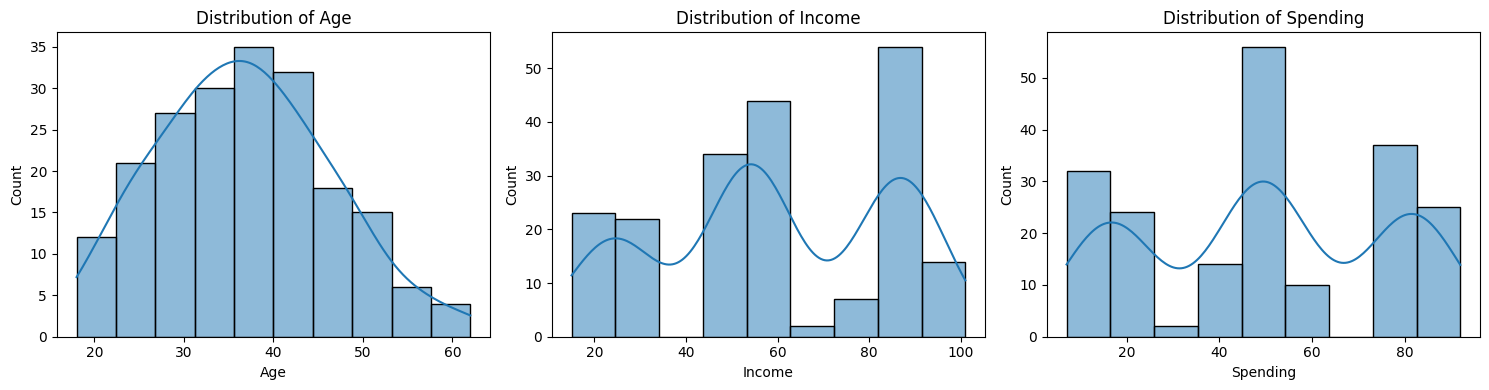

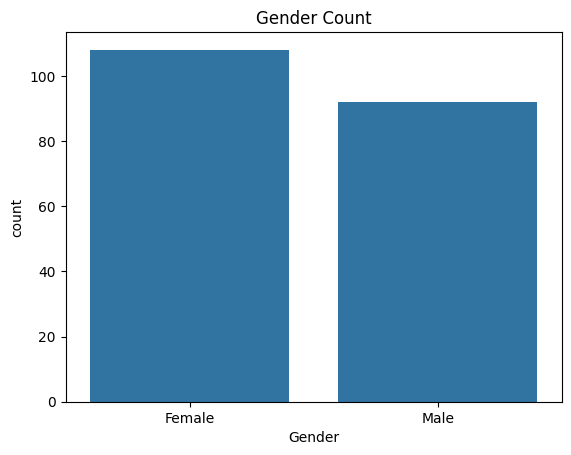

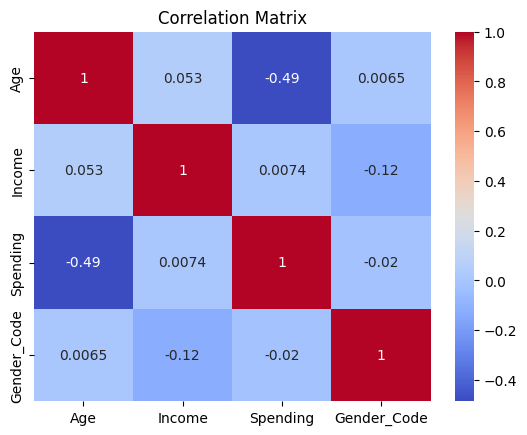

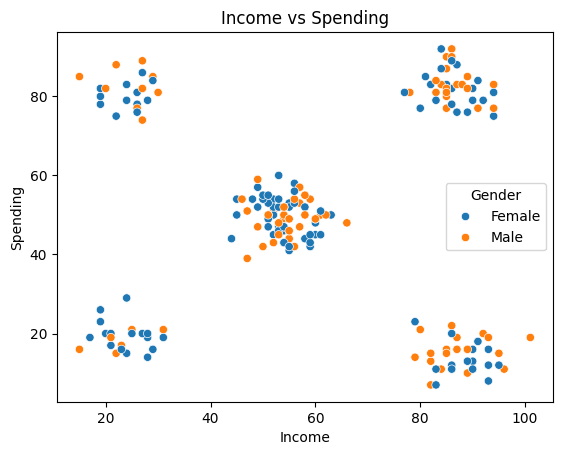

In [7]:
#EDA
# Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Age", "Income", "Spending"]):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Gender count
sns.countplot(x="Gender", data=df)
plt.title("Gender Count")
plt.show()

# Correlation heatmap
sns.heatmap(df[["Age", "Income", "Spending", "Gender_Code"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Relationship between income and spending
sns.scatterplot(x="Income", y="Spending", hue="Gender", data=df)
plt.title("Income vs Spending")
plt.show()

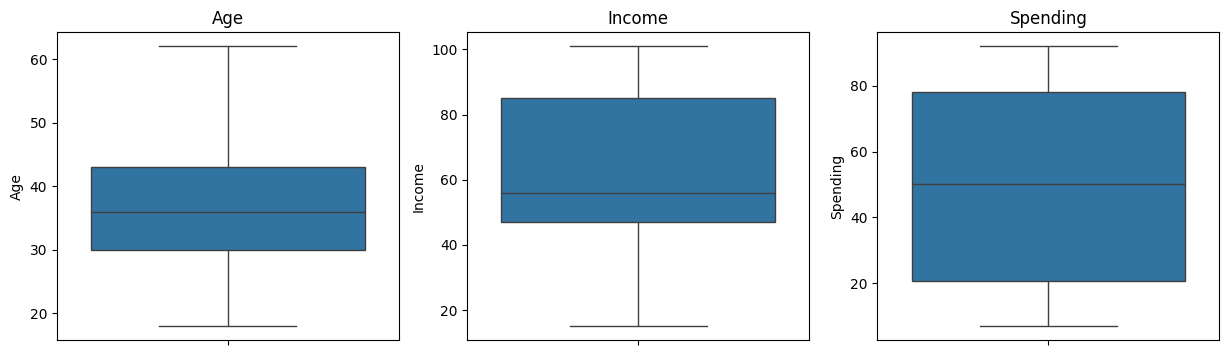

In [8]:
#Outlier check
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Age", "Income", "Spending"]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.show()

In [9]:
#Feature selection
X = df[["Income", "Spending"]]                 # ONLY these two, no Age
X_scaled = StandardScaler().fit_transform(X)

In [10]:
#Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

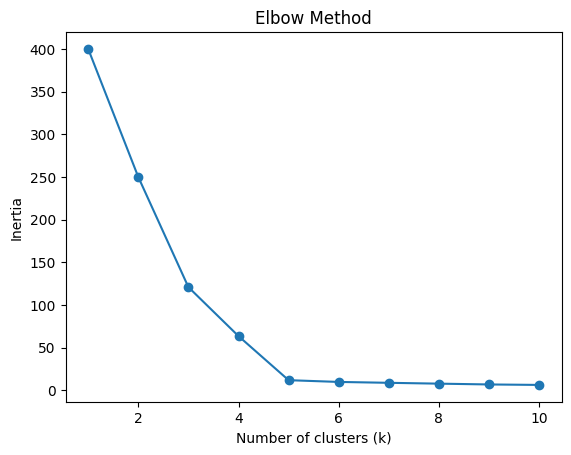

In [11]:
#Elbow method
inertia = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

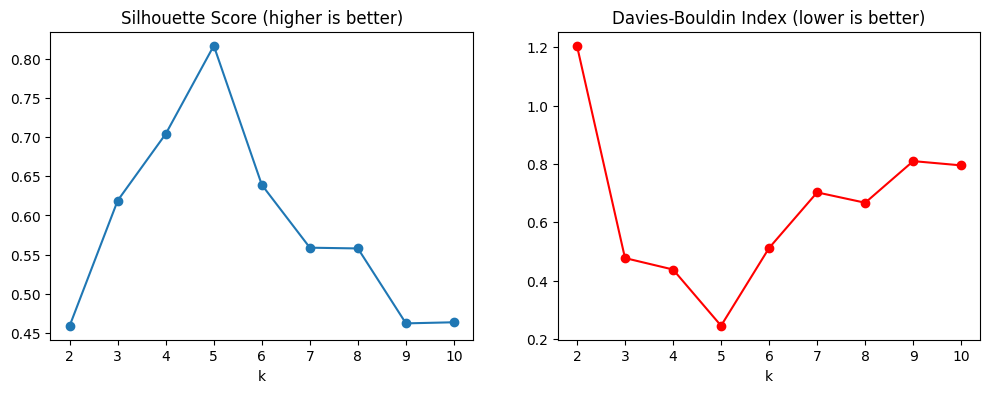

Best k by silhouette: 5


In [12]:
#Silhouette and Davies-Bouldin scores
sil_scores = []
db_scores = []
K = range(2, 11)

for k in K:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K, sil_scores, marker="o")
axes[0].set_title("Silhouette Score (higher is better)")
axes[0].set_xlabel("k")

axes[1].plot(K, db_scores, marker="o", color="red")
axes[1].set_title("Davies-Bouldin Index (lower is better)")
axes[1].set_xlabel("k")
plt.show()

best_k = K[np.argmax(sil_scores)]
print("Best k by silhouette:", best_k)

In [13]:
#Train the final K-Means model
k = 5   # change based on your elbow/silhouette results

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df["Cluster"].value_counts().sort_index())

Cluster
0    35
1    80
2    40
3    23
4    22
Name: count, dtype: int64


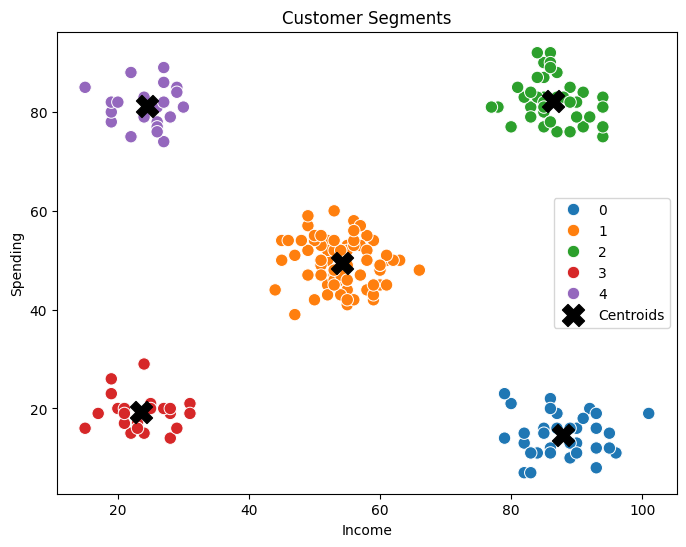

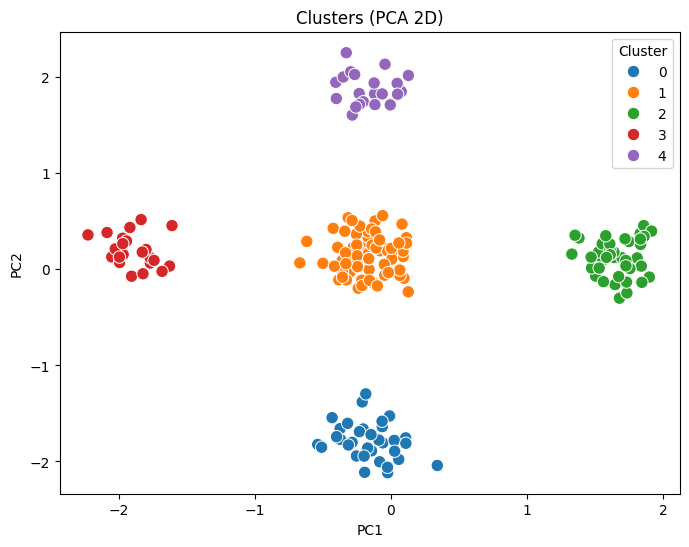

In [18]:
#Visualize the clusters
# 2D view: Income vs Spending
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Income", y="Spending", hue="Cluster",
                palette="tab10", data=df, s=80)

# Plot centroids (convert back to original scale)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c="black", s=250,
            marker="X", label="Centroids")
plt.title("Customer Segments")
plt.legend()
plt.show()

# PCA view (works with any number of features)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1], hue=df["Cluster"], palette="tab10", s=80)
plt.title("Clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [15]:
#Profile the segments
profile = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Income=("Income", "mean"),
    Avg_Spending=("Spending", "mean"),
    Female_Pct=("Gender_Code", "mean")
).round(1)

profile["Female_Pct"] = (profile["Female_Pct"] * 100).round(1)
print(profile)

         Customers  Avg_Age  Avg_Income  Avg_Spending  Female_Pct
Cluster                                                          
0               35     40.2        87.9          14.7        40.0
1               80     40.3        54.2          49.4        60.0
2               40     31.3        86.4          82.3        50.0
3               23     41.3        23.6          19.2        70.0
4               22     23.1        24.5          81.2        50.0


In [16]:
#Name the segments
segment_names = {
    0: "Standard Customers",
    1: "Target: High Income, High Spending",
    2: "Careful: High Income, Low Spending",
    3: "Sensible: Low Income, Low Spending",
    4: "Impulsive: Low Income, High Spending"
}

df["Segment"] = df["Cluster"].map(segment_names)
print(df["Segment"].value_counts())

Segment
Target: High Income, High Spending      80
Careful: High Income, Low Spending      40
Standard Customers                      35
Sensible: Low Income, Low Spending      23
Impulsive: Low Income, High Spending    22
Name: count, dtype: int64


Cluster
0    0.826
1    0.794
2    0.833
3    0.835
4    0.834
Name: Silhouette, dtype: float64
Customers with silhouette < 0.1: 0


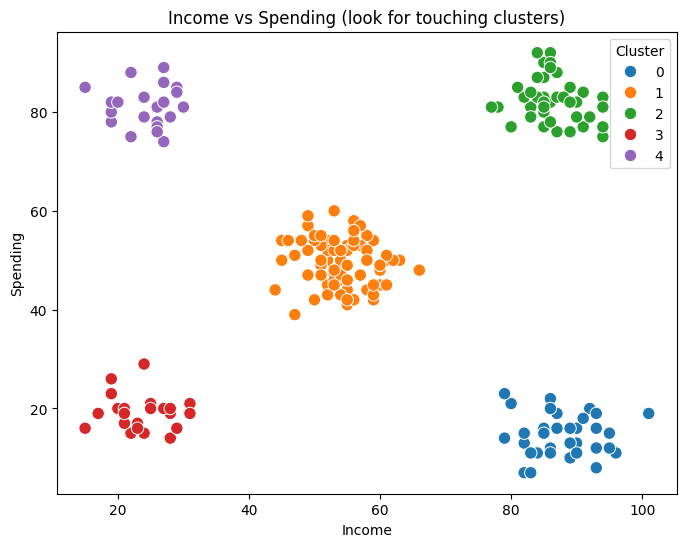

In [17]:
from sklearn.metrics import silhouette_samples

# Per-customer silhouette: low or negative = probably on a cluster boundary
df["Silhouette"] = silhouette_samples(X_scaled, df["Cluster"])
print(df.groupby("Cluster")["Silhouette"].mean().round(3))
print("Customers with silhouette < 0.1:", (df["Silhouette"] < 0.1).sum())

# Visual check on the two main features
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Income", y="Spending", hue="Cluster", palette="tab10", data=df, s=80)
plt.title("Income vs Spending (look for touching clusters)")
plt.show()